Variance of Laplacian: 245.7865188655536
(739, 400)


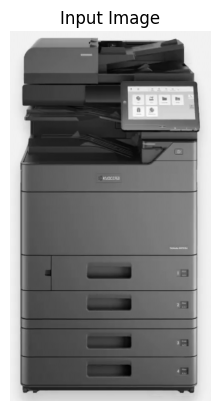

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/usr/src/app/data/output/crops/frame_00002_a_salient_object_00.png")  # Load the image
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # Convert to grayscale

# Apply Laplacian filter
laplacian = cv2.Laplacian(img, cv2.CV_64F)

# Calculate variance of the Laplacian
# Higher variance indicates more edges/details, thus higher perceived sharpness
variance = np.var(laplacian)

print(f"Variance of Laplacian: {variance}")
print(img.shape)

#   Display the image (optional)
plt.imshow(img, cmap='gray')
plt.title('Input Image')
plt.axis('off')
plt.show()

In [19]:
import torch

def center_to_corners_format(boxes):
    """
    Args:
        boxes: (N, 4) テンソル。各行は [cx, cy, w, h] 形式
    Returns:
        (N, 4) テンソル。各行は [x1, y1, x2, y2] 形式
    """
    cx, cy, w, h = boxes.unbind(-1)
    x1 = cx - w / 2
    y1 = cy - h / 2
    x2 = cx + w / 2
    y2 = cy + h / 2
    return torch.stack([x1, y1, x2, y2], dim=-1)


batch_boxes = torch.tensor([[50, 60, 20, 40], [30, 40, 10, 10]], dtype=torch.float)
corners = center_to_corners_format(batch_boxes)
print(corners)

tensor([[40., 40., 60., 80.],
        [25., 35., 35., 45.]])


Video Intelligence

In [7]:
# !pip install google-cloud-videointelligence

In [8]:
from google.cloud import videointelligence

In [9]:
video_client = videointelligence.VideoIntelligenceServiceClient() # クライアントの初期化
features = [videointelligence.Feature.LABEL_DETECTION] # 機能の指定（ここではラベル検出）

In [51]:
# パス
path = "/usr/src/app/data/taskalfa.mp4"

import io

# 動画読み込み
with io.open(path, "rb") as movie:
    input_content = movie.read()

In [52]:
# リクエストの実行
operation = video_client.annotate_video(
    request={"features": features, "input_content": input_content}
)

operation

In [53]:
result = operation.result()

In [54]:
result

annotation_results {
  segment_label_annotations {
    entity {
      entity_id: "/m/01m4t"
      description: "printer"
      language_code: "en-US"
    }
    category_entities {
      entity_id: "/m/07c1v"
      description: "technology"
      language_code: "en-US"
    }
    segments {
      segment {
        start_time_offset {
        }
        end_time_offset {
          seconds: 74
          nanos: 941533000
        }
      }
      confidence: 0.919685483
    }
  }
  segment_label_annotations {
    entity {
      entity_id: "/m/01cd9"
      description: "brand"
      language_code: "en-US"
    }
    segments {
      segment {
        start_time_offset {
        }
        end_time_offset {
          seconds: 74
          nanos: 941533000
        }
      }
      confidence: 0.400958031
    }
  }
  segment_label_annotations {
    entity {
      entity_id: "/m/0c5mq"
      description: "printing"
      language_code: "en-US"
    }
    category_entities {
      entity_id: "/m/0jjw"
 

In [57]:
result.annotation_results[0]

segment_label_annotations {
  entity {
    entity_id: "/m/01m4t"
    description: "printer"
    language_code: "en-US"
  }
  category_entities {
    entity_id: "/m/07c1v"
    description: "technology"
    language_code: "en-US"
  }
  segments {
    segment {
      start_time_offset {
      }
      end_time_offset {
        seconds: 74
        nanos: 941533000
      }
    }
    confidence: 0.919685483
  }
}
segment_label_annotations {
  entity {
    entity_id: "/m/01cd9"
    description: "brand"
    language_code: "en-US"
  }
  segments {
    segment {
      start_time_offset {
      }
      end_time_offset {
        seconds: 74
        nanos: 941533000
      }
    }
    confidence: 0.400958031
  }
}
segment_label_annotations {
  entity {
    entity_id: "/m/0c5mq"
    description: "printing"
    language_code: "en-US"
  }
  category_entities {
    entity_id: "/m/0jjw"
    description: "art"
    language_code: "en-US"
  }
  segments {
    segment {
      start_time_offset {
      }
     

In [58]:
segment_labels = result.annotation_results[0].segment_label_annotations

In [59]:
len(segment_labels)

4

In [63]:
segment_labels[2]

entity {
  entity_id: "/m/0c5mq"
  description: "printing"
  language_code: "en-US"
}
category_entities {
  entity_id: "/m/0jjw"
  description: "art"
  language_code: "en-US"
}
segments {
  segment {
    start_time_offset {
    }
    end_time_offset {
      seconds: 74
      nanos: 941533000
    }
  }
  confidence: 0.713107407
}